# Example: EWLS Engine Replay

In this example, we replay the Cobb-Douglas rebalancing engine with **exponentially weighted least squares (EWLS)** parameter updates. Instead of using frozen SIM parameters from a historical calibration window, the engine re-estimates $(\alpha_i, \beta_i, \sigma_{\varepsilon,i})$ daily as new market data arrives.

The Session 2 engine froze its SIM parameters at calibration time. That is defensible if the world stops changing, and indefensible if it does not. This example deliberately runs the engine on paths where the true $(\alpha_i, \beta_i)$ have drifted off the calibration, and asks: when does updating online pay for itself, and what does it cost on the paths where it does not?

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Run the EWLS engine on a Monte Carlo ensemble:__ Replay the engine with online parameter updates across hundreds of synthetic paths and compare the distributional performance against the frozen-parameter baseline. Read the median terminal wealth, drawdown, and Sharpe statistics to judge whether online adaptation tightens the outcome distribution.
> * __Visualize parameter drift on single paths:__ Select individual paths and plot how the engine's SIM intercept and slope estimates evolve over the trading horizon. Use these trajectories to see the engine adapting to regime shifts that the frozen baseline cannot react to.
> * __Sweep the half-life for bias-variance trade-off:__ Run the EWLS engine at three half-life values and compare how quickly the estimates track regime shifts versus how much noise they introduce. Identify the half-life that balances responsiveness against estimation noise on a single realized path.

Let's see what happens when the engine's world-model updates itself. We'll compare the frozen and online engines on the Session 2 Monte Carlo ensemble, then zoom into single paths to see what one realized future looks like.

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations.

See the comments in the code for more details on each constant, its purpose, units, etc.

In [8]:
# EWLS replay configuration
B₀ = 10_000.0                  # starting budget (USD)
Δt = 1.0 / 252.0               # trading-day step (years)
L_short = 21                   # short EMA window (days) for the sentiment crossover
L_long = 63                    # long EMA window (days) for the sentiment crossover
L_growth = 10                  # EMA window (days) for smoothed market growth rate
GAIN = 10.0                    # gain constant G for the λ sentiment signal (dimensionless)
offset = L_short + L_long      # warmup offset before trading begins (days)
SCENARIO_SEED = 2026           # RNG seed for the hybrid-SIM scenario (locked across Examples 1-2)
N_ENSEMBLE_PATHS = 500         # number of Monte Carlo paths in the EWLS-vs-frozen comparison
N_ACTIVE_TRADING_DAYS = 252    # trading horizon after warmup (days)
EWLS_HALF_LIFE = 63.0          # default EWLS decay half-life (trading days)
EWLS_PRIOR_WEIGHT = 63.0       # pseudo-observation count anchoring estimates to S1 calibration
DRIFT_SCALE = 6.0              # bootstrap-SE multiplier for per-path (α, β) parameter drift
DRIFT_SEED = 42                # RNG seed for the per-path parameter drift draws
ENGINE_PRIOR_CCGR_PCT = 8.0    # prior CCGR anchor (% /yr) for bias correction (same as Session 2)
TRIGGER_MAX_DRAWDOWN = 0.15    # drawdown trigger threshold (de-risks to cash, fraction)
TRIGGER_MAX_TURNOVER = 0.50    # max fraction of wealth traded per rebalance
HALF_LIFE_PATH_IDX = 25;         # path index (1-indexed) used in the Task 3 half-life sweep

### Implementation
We define the bias-correction helper used by Task 1.

> __`apply_bias_correction(r, bias_pct_per_yr, Δt)`__
>
> Apply a uniform exponential drag $W_{\text{corr}}(t) = W(t) \cdot e^{-\delta\,t}$ (where $\delta = \text{bias\_pct\_per\_yr}/100$) to every path in `r::MyBacktestResult`, then recompute `final_wealth`, `max_drawdowns`, and `sharpe_ratios` from the corrected paths. Returns a new [`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestResult) with the strategy label annotated with the applied drag in pp/yr.

The helper definition appears in the code block below.

In [9]:
function apply_bias_correction(r::MyBacktestResult, bias_pct_per_yr::Float64,
        Δt::Float64)::MyBacktestResult
    n_t, n_p = size(r.wealth_paths);
    drag = exp.(-bias_pct_per_yr / 100.0 .* (0:(n_t-1)) .* Δt);
    Wc = r.wealth_paths .* drag;
    final_wealth_c  = Wc[end, :];
    max_drawdowns_c = zeros(n_p);
    sharpe_ratios_c = zeros(n_p);
    for p ∈ 1:n_p
        wealth = Wc[:, p];
        peak = accumulate(max, wealth);
        max_drawdowns_c[p] = maximum((peak .- wealth) ./ peak);
        vol = std(diff(wealth) ./ wealth[1:end-1]) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios_c[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end
    rc = MyBacktestResult();
    rc.scenario_label = r.scenario_label;
    rc.strategy_label = r.strategy_label * " [bias-corrected $(round(bias_pct_per_yr, digits=2))pp/yr]";
    rc.final_wealth   = final_wealth_c;
    rc.max_drawdowns  = max_drawdowns_c;
    rc.sharpe_ratios  = sharpe_ratios_c;
    rc.wealth_paths   = Wc;
    return rc;
end;


Load the Session 1 artifacts (SIM parameter estimates, ticker universe, etc.) and the pre-trained surrogates needed for scenario generation.

In the code block below, we populate the following top-level bindings:

| Binding | Type | Description |
|---|---|---|
| `my_tickers` | `Vector{String}` | Ticker universe from the Session 1 calibration. |
| `N` | `Int` | Number of tickers (`length(my_tickers)`). |
| `sim_estimates` | `Vector{MySIMParameterEstimate}` | Per-ticker SIM fits. Fields: $\alpha$ (Jensen's alpha, yr$^{-1}$), $\beta$ (market beta), $\sigma_\varepsilon$ (residual std, yr$^{-1}$), $r^2$, and `ticker`. |
| `sim_params` | `Dict{String,Tuple{Float64,Float64,Float64}}` | Allocator-adapter view: ticker $\mapsto (\alpha, \beta, \sigma_\varepsilon)$. Consumed by [`backtest_engine(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_engine) and [`replay_engine_ewls(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.replay_engine_ewls). |
| `σ_m` | `Float64` | Market volatility, annualized growth-rate units. |
| `g_f` | `Float64` | Continuously-compounded annual risk-free rate (yr$^{-1}$). |
| `market_model` | [`MyMarketSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel) | Trained JumpHMM market surrogate. |
| `portfolio` | [`MyPortfolioSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel) | Portfolio-level surrogate composing per-ticker paths from SIM and the market surrogate. |
| `calib` | `Dict{String,Any}` | Full SIM calibration dict; source of truth for $\alpha$, $\beta$, $\sigma_\varepsilon$ and bootstrap SEs. |
| `start_prices` | `Dict{String,Float64}` | Per-ticker starting prices for forward scenarios. |


In [10]:
(; my_tickers, sim_estimates, sim_params, σ_m, g_f,
   market_model, portfolio, calib, start_prices, N) = let
    # --- Step 1: Load S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers    = minvar["my_tickers"]::Vector{String};
    sim_estimates = minvar["sim_estimates"];
    g_f           = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : Float64(minvar["r_f"]);

    # --- Step 2: Build SIM parameter dictionary ---
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e in sim_estimates
    );
    σ_m = minvar["sigma_market"]::Float64;

    # --- Step 3: Load surrogates and calibration ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap        = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t in my_tickers);

    # --- Step 4: Constants ---
    N         = length(my_tickers);

    println("Loaded $(N) tickers: $(my_tickers)")
    println("Risk-free growth rate: $(round(g_f*100, digits=2))%/yr")
    (my_tickers = my_tickers, sim_estimates = sim_estimates, sim_params = sim_params,
     σ_m = σ_m, g_f = g_f, market_model = market_model, portfolio = portfolio,
     calib = calib, start_prices = start_prices, N = N)
end;

Loaded 20 tickers: ["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"]
Risk-free growth rate: 4.5%/yr


___
## Task 1: Frozen vs. Online on the Monte Carlo Ensemble
In this task, we generate a 500-path drifted hybrid scenario via [the `generate_drifted_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_drifted_hybrid_scenario). Each path draws its true $(\alpha_i, \beta_i)$ from a distribution centered at the historical calibration with spread `DRIFT_SCALE` bootstrap standard errors — so the frozen calibration values are genuinely stale on every path. We then run the same Cobb-Douglas rebalancing engine twice on each path: once with the SIM parameters $(\alpha_i, \beta_i, \sigma_{\varepsilon,i})$ held at the frozen calibration values, and once with EWLS re-estimating those parameters daily as new data arrives (half-life $h = 63$ trading days).

> __What should we see?__
>
> Both runs use identical trigger rules, allocator, and price paths; the only difference is whether the SIM parameters update online. The drifted generator gives every path a different true $(\alpha_i, \beta_i)$, drawn `DRIFT_SCALE` bootstrap standard errors from the calibration point estimate. Frozen uses the stale calibration values throughout; EWLS detects the mismatch and adjusts preference weights toward the path's true parameters. The distributional table should show EWLS winning on a meaningful fraction of paths — the engine earns its cost precisely because the calibration is no longer correct.


In the code block below, we generate the drifted scenario, run both engines on each path, apply bias correction anchored to `ENGINE_PRIOR_CCGR_PCT`, and display the distributional comparison table.

In [11]:
scenario, frozen_bt, ewls_final_wealth, bias_pct_per_yr = let
    # --- Step 1: Generate the 500-path drifted scenario ---
    n_paths = N_ENSEMBLE_PATHS;
    n_trading_days = N_ACTIVE_TRADING_DAYS;
    T_total = offset + n_trading_days;

    scenario = generate_drifted_hybrid_scenario(
        market_model, portfolio, calib, my_tickers;
        n_paths = n_paths, n_steps = T_total,
        start_prices = start_prices, label = "S3 EWLS Ensemble (drifted)", seed = SCENARIO_SEED,
        drift_scale = DRIFT_SCALE, drift_seed = DRIFT_SEED);

    # --- Step 2: Run the frozen-parameter engine via backtest_engine ---
    rules_params = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);
    frozen_bt = backtest_engine(scenario, my_tickers, sim_params, rules_params;
        B₀ = B₀, offset = offset);

    # --- Step 3: Run EWLS engine across all paths, storing full wealth paths ---
    n_trading = T_total - offset;
    ewls_final_wealth = zeros(n_paths);
    ewls_max_dd       = zeros(n_paths);
    ewls_sharpe       = zeros(n_paths);
    ewls_wealth_paths = zeros(n_trading + 1, n_paths);  # store for bias correction

    for p in 1:n_paths
        mkt = scenario.market_paths[p, :];
        pmatrix = zeros(T_total, N + 1);
        pmatrix[:, 1] = 1:T_total;
        for k in 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        result = replay_engine_ewls(pmatrix, mkt, my_tickers, sim_params, rules_params;
            B₀ = B₀, offset = offset, half_life = EWLS_HALF_LIFE, prior_weight = EWLS_PRIOR_WEIGHT,
            N_short = L_short, N_long = L_long, GAIN = GAIN, N_growth = L_growth);

        w = result.wealth;
        ewls_wealth_paths[:, p] .= w;
        ewls_final_wealth[p] = w[end];
        returns_p = diff(w) ./ w[1:end-1];
        peak_p = accumulate(max, w);
        ewls_max_dd[p] = maximum((peak_p .- w) ./ peak_p);
        vol_p = std(returns_p) * sqrt(252);
        ewls_sharpe[p] = vol_p > 0 ? (w[end]/w[1] - 1.0) / vol_p : 0.0;
    end

    # --- Step 4: Bias correction (same anchor as Session 2) ---
    # Compute frozen engine's raw median CCGR, then apply the drag that anchors it to ENGINE_PRIOR_CCGR_PCT.
    # The same drag is applied to EWLS so absolute levels are comparable; relative advantage is preserved.
    frozen_raw_med_ccgr = let
        gs = Float64[];
        for p ∈ 1:n_paths
            w = frozen_bt.wealth_paths[:, p];
            push!(gs, log(w[end] / w[1]) / ((length(w) - 1) * Δt) * 100);
        end
        median(gs)
    end;
    bias_pct_per_yr = frozen_raw_med_ccgr - ENGINE_PRIOR_CCGR_PCT;
    println("  Frozen raw median CCGR:  $(round(frozen_raw_med_ccgr, digits=2)) %/yr");
    println("  ENGINE_PRIOR_CCGR_PCT:   $(ENGINE_PRIOR_CCGR_PCT) %/yr");
    println("  Bias correction drag:    $(round(bias_pct_per_yr, digits=2)) pp/yr");

    frozen_bt_c = apply_bias_correction(frozen_bt, bias_pct_per_yr, Δt);

    ewls_bt_raw = MyBacktestResult();
    ewls_bt_raw.scenario_label = scenario.label;
    ewls_bt_raw.strategy_label = "EWLS h=$(Int(EWLS_HALF_LIFE))d raw";
    ewls_bt_raw.final_wealth   = ewls_final_wealth;
    ewls_bt_raw.max_drawdowns  = ewls_max_dd;
    ewls_bt_raw.sharpe_ratios  = ewls_sharpe;
    ewls_bt_raw.wealth_paths   = ewls_wealth_paths;
    ewls_bt_c = apply_bias_correction(ewls_bt_raw, bias_pct_per_yr, Δt);
    ewls_final_wealth_c = ewls_bt_c.final_wealth;
    ewls_max_dd_c       = ewls_bt_c.max_drawdowns;
    ewls_sharpe_c       = ewls_bt_c.sharpe_ratios;

    # --- Step 5: Per-path NPV against the continuously-compounded risk-free baseline ---
    T_active   = N_ACTIVE_TRADING_DAYS * Δt;
    discount   = exp(-g_f * T_active);
    frozen_npv = frozen_bt_c.final_wealth .* discount .- B₀;
    ewls_npv   = ewls_final_wealth_c      .* discount .- B₀;

    # --- Step 6: Build the distributional comparison DataFrame ---
    comparison_df = DataFrame(
        "Metric"                 => ["Median W/W₀", "Median Max DD (%)", "Median Sharpe",
                                     "Fail rate P[W<B₀] (%)", "Median NPV (\$)", "Median NPV (% of B₀)",
                                     "P[NPV<0] (%)"],
        "Frozen (corrected)"     => [
            round(median(frozen_bt_c.final_wealth) / B₀, digits = 3),
            round(median(frozen_bt_c.max_drawdowns) * 100, digits = 1),
            round(median(frozen_bt_c.sharpe_ratios), digits = 3),
            round(mean(frozen_bt_c.final_wealth .< B₀) * 100, digits = 1),
            round(median(frozen_npv),                digits = 0),
            round(median(frozen_npv) / B₀ * 100,     digits = 2),
            round(mean(frozen_npv .< 0) * 100,       digits = 1),
        ],
        "EWLS h=63 (corrected)" => [
            round(median(ewls_final_wealth_c) / B₀, digits = 3),
            round(median(ewls_max_dd_c) * 100, digits = 1),
            round(median(ewls_sharpe_c), digits = 3),
            round(mean(ewls_final_wealth_c .< B₀) * 100, digits = 1),
            round(median(ewls_npv),              digits = 0),
            round(median(ewls_npv) / B₀ * 100,   digits = 2),
            round(mean(ewls_npv .< 0) * 100,     digits = 1),
        ],
    );
    n_ewls_wins = sum(ewls_final_wealth_c .> frozen_bt_c.final_wealth);
    println("Frozen vs EWLS engine: distributional comparison ($(n_paths) paths)");
    println("EWLS outperforms frozen on $(n_ewls_wins)/$(n_paths) paths ($(round(n_ewls_wins/n_paths*100, digits=1))%)");
    pretty_table(comparison_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    # --- Step 7: Save for downstream examples ---
    save_results(joinpath(_PATH_TO_DATA, "ewls-replay-results.jld2"), Dict(
        "frozen_final_wealth" => frozen_bt_c.final_wealth,
        "frozen_max_dd"       => frozen_bt_c.max_drawdowns,
        "frozen_sharpe"       => frozen_bt_c.sharpe_ratios,
        "frozen_npv"          => frozen_npv,
        "ewls_final_wealth"   => ewls_final_wealth_c,
        "ewls_max_dd"         => ewls_max_dd_c,
        "ewls_sharpe"         => ewls_sharpe_c,
        "ewls_npv"            => ewls_npv,
        "bias_pct_per_yr"     => bias_pct_per_yr,
        "n_paths"             => n_paths,
        "my_tickers"          => my_tickers,
        "sim_params"          => sim_params,
        "g_f"                 => g_f,
        "T_active"            => T_active,
    ));
    println("Saved results to ewls-replay-results.jld2");
    scenario, frozen_bt_c, ewls_final_wealth_c, bias_pct_per_yr
end;


  Frozen raw median CCGR:  32.51 %/yr
  ENGINE_PRIOR_CCGR_PCT:   8.0 %/yr
  Bias correction drag:    24.51 pp/yr
Frozen vs EWLS engine: distributional comparison (500 paths)
EWLS outperforms frozen on 375/500 paths (75.0%)
 ----------------------- -------------------- -----------------------
                 Metric   Frozen (corrected)   EWLS h=63 (corrected) 
                 String              Float64                 Float64 
 ----------------------- -------------------- -----------------------
            Median W/W₀                1.083                   1.144
      Median Max DD (%)                  9.0                    10.0
          Median Sharpe                0.632                    0.92
  Fail rate P[W<B₀] (%)                 22.6                    16.2
         Median NPV ($)                356.0                   939.0
   Median NPV (% of B₀)                 3.56                    9.39
           P[NPV<0] (%)                 38.4                    26.0
 -------------

___
## Task 2: Single-Path Replay: One Realized Future
In this task, we select three paths from the ensemble and replay the EWLS engine on each, plotting the wealth trajectory alongside the SIM parameter drift. Two paths are chosen where EWLS outperforms frozen by the largest margin; one path is chosen where frozen outperforms EWLS by the largest margin. This contrast shows that EWLS tracking is not free: on some paths, the frozen calibration turns out to be close enough that the online adaptation adds noise rather than signal. The replay calls [the `replay_engine_ewls(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.replay_engine_ewls) per path.

> __What should we see?__
>
> On the two EWLS-wins paths, the $\alpha$ and $\beta$ estimates should drift noticeably away from the frozen calibration values, and the wealth advantage compounds at precisely those points. On the frozen-wins path, the parameter drift is smaller or slower — the calibration happened to be close enough to the path's true generating parameters that adapting online added noise rather than correcting a meaningful error. The frozen-wins path is not a failure of EWLS; it is the cost that every adaptive engine pays: on any given realization, tracking can lag or overshoot, and the diversification benefit of the ensemble does not apply to a single path.
>
> Every path has genuine parameter drift built in — the drifted generator ensures the calibration is wrong on every path. The two EWLS-wins paths show where tracking was fast enough to recover calibration error before the end of the horizon; the frozen-wins path shows where tracking was too slow or noisy relative to the drift it was chasing.

In the code block below, we sort paths by the EWLS–frozen wealth advantage, pick the top two (EWLS wins most) and the bottom one (frozen wins most), and render a three-panel figure per path: a wealth trajectory with the frozen baseline above (title annotated with who won), an α-drift series for the first two tickers in the middle, and a β-drift series below.


Selected paths: [260, 427, 477]
  EWLS-advantage ($): [4081.4, 4363.0, -4927.7]


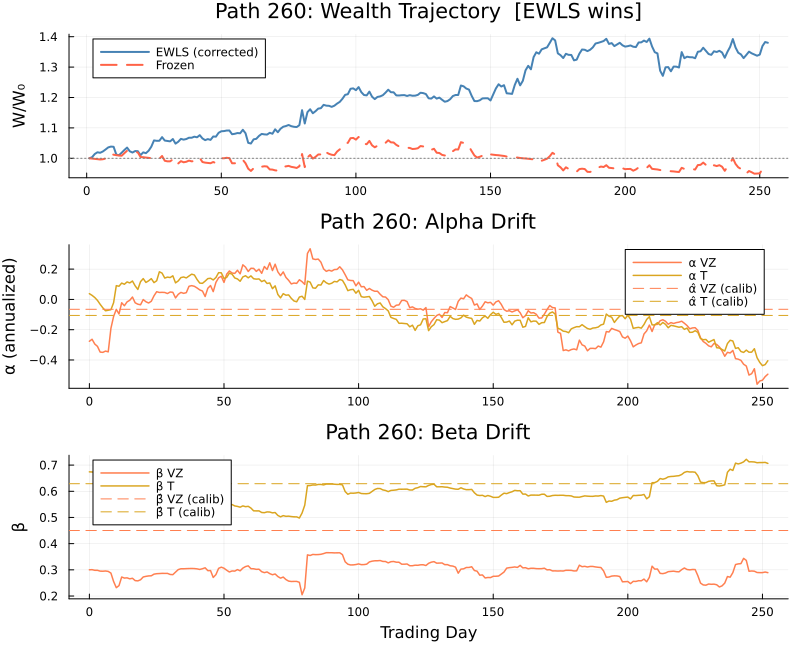

Path 260 [EWLS wins]: EWLS W/W₀ = 1.38,  Frozen W/W₀ = 0.972


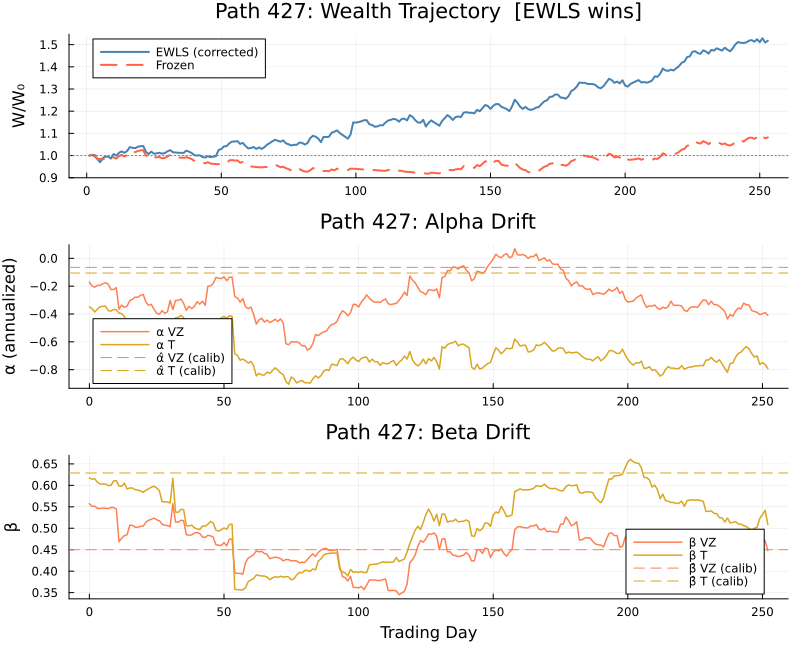

Path 427 [EWLS wins]: EWLS W/W₀ = 1.518,  Frozen W/W₀ = 1.081


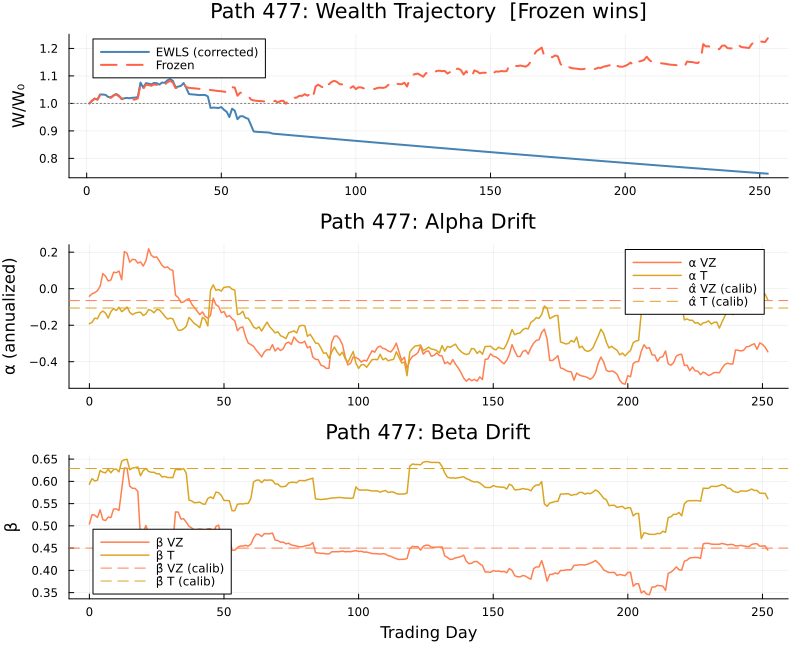

Path 477 [Frozen wins]: EWLS W/W₀ = 0.744,  Frozen W/W₀ = 1.237


In [12]:
let
    # --- Step 1: Select 2 EWLS-wins paths + 1 frozen-wins path ---
    ewls_advantage = ewls_final_wealth .- frozen_bt.final_wealth;
    ewls_top2   = partialsortperm(ewls_advantage, 1:2, rev=true);   # EWLS wins most
    frozen_top1 = partialsortperm(ewls_advantage, 1:1);              # frozen wins most
    sample_paths = sort(vcat(ewls_top2, frozen_top1));
    winner_label = [p ∈ ewls_top2 ? "EWLS wins" : "Frozen wins" for p ∈ sample_paths];
    println("Selected paths: $(sample_paths)");
    println("  EWLS-advantage (\$): $(round.(ewls_advantage[sample_paths], digits=1))");

    rules_params = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);
    T_total = scenario.n_steps;

    for (j, p) in enumerate(sample_paths)
        mkt = scenario.market_paths[p, :];
        pmatrix = zeros(T_total, N + 1);
        pmatrix[:, 1] = 1:T_total;
        for k in 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        # --- Step 2: Run EWLS engine ---
        result = replay_engine_ewls(pmatrix, mkt, my_tickers, sim_params, rules_params;
            B₀ = B₀, offset = offset, half_life = EWLS_HALF_LIFE, prior_weight = EWLS_PRIOR_WEIGHT,
            N_short = L_short, N_long = L_long, GAIN = GAIN, N_growth = L_growth);

        # --- Panel 1: Wealth trajectory (EWLS corrected vs frozen baseline) ---
        bias_drag = exp.(-bias_pct_per_yr / 100.0 .* (0:length(result.wealth)-1) .* Δt);
        wealth_c = result.wealth .* bias_drag;
        days = 1:length(wealth_c);
        frozen_w = frozen_bt.wealth_paths[:, p];
        lbl = winner_label[j];
        p1 = plot(days, wealth_c ./ B₀, label="EWLS (corrected)", linewidth=2, color=:steelblue,
            ylabel="W/W₀", title="Path $(p): Wealth Trajectory  [$(lbl)]")
        plot!(p1, days, frozen_w ./ B₀, label="Frozen", linewidth=2, color=:tomato, linestyle=:dash)
        hline!(p1, [1.0], linestyle=:dot, color=:gray50, label="")

        # --- Panel 2: Alpha drift for first two tickers ---
        t1, t2 = my_tickers[1], my_tickers[2];
        α_1 = [h[1] for h in result.param_history[t1]];
        α_2 = [h[1] for h in result.param_history[t2]];
        p2 = plot(0:length(α_1)-1, α_1, label="α $(t1)", linewidth=1.5, color=:coral,
            ylabel="α (annualized)", title="Path $(p): Alpha Drift")
        plot!(p2, 0:length(α_2)-1, α_2, label="α $(t2)", linewidth=1.5, color=:goldenrod)
        hline!(p2, [sim_params[t1][1]], linestyle=:dash, color=:coral,   linewidth=1, label="α̂ $(t1) (calib)")
        hline!(p2, [sim_params[t2][1]], linestyle=:dash, color=:goldenrod, linewidth=1, label="α̂ $(t2) (calib)")

        # --- Panel 3: Beta drift for first two tickers ---
        β_1 = [h[2] for h in result.param_history[t1]];
        β_2 = [h[2] for h in result.param_history[t2]];
        p3 = plot(0:length(β_1)-1, β_1, label="β $(t1)", linewidth=1.5, color=:coral,
            ylabel="β", title="Path $(p): Beta Drift", xlabel="Trading Day")
        plot!(p3, 0:length(β_2)-1, β_2, label="β $(t2)", linewidth=1.5, color=:goldenrod)
        hline!(p3, [sim_params[t1][2]], linestyle=:dash, color=:coral,   linewidth=1, label="β̂ $(t1) (calib)")
        hline!(p3, [sim_params[t2][2]], linestyle=:dash, color=:goldenrod, linewidth=1, label="β̂ $(t2) (calib)")

        display(plot(p1, p2, p3, layout=(3,1), size=(800, 650)))
        println("Path $(p) [$(lbl)]: EWLS W/W₀ = $(round(wealth_c[end]/B₀, digits=3)),  Frozen W/W₀ = $(round(frozen_w[end]/B₀, digits=3))")
    end
end;


___
## Task 3: Half-Life Sensitivity
In this task, we sweep three half-life values $h \in \{21, 63, 126\}$ days on a single path to see the bias-variance trade-off in action. Short half-lives track regime shifts fast but amplify noise; long half-lives are stable but slow. Each sweep value calls [`replay_engine_ewls(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.replay_engine_ewls) with that half-life.

> __What should we see?__
>
> The $h = 21$ estimates should be noisy but responsive. The $h = 126$ estimates should be smooth but lag behind regime transitions. The $h = 63$ default should sit between the two. The $\alpha$ and $\beta$ panels make the bias-variance trade-off visible: a short half-life produces jagged, rapidly adapting parameter tracks, while a long half-life produces smooth tracks that are slow to react to the path's drifted true values.

In the code block below, we run the sweep on path `HALF_LIFE_PATH_IDX` and overlay the three wealth trajectories, $\alpha$ paths, and $\beta$ paths on a three-panel figure.


h=21:  W/W₀ = 0.942
h=63:  W/W₀ = 0.999
h=126:  W/W₀ = 1.017


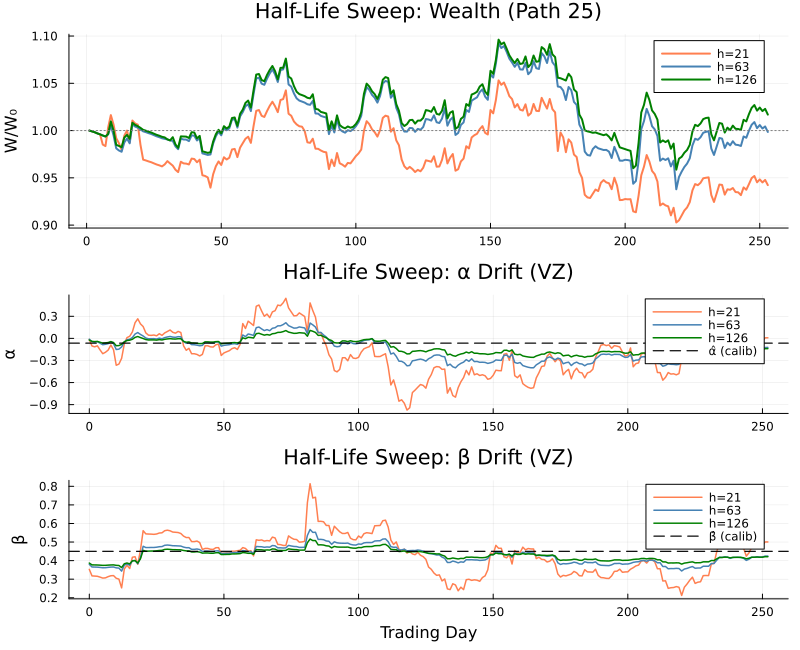

In [13]:
let
    # --- Step 1: Pick a single path ---
    p_idx = HALF_LIFE_PATH_IDX;
    mkt = scenario.market_paths[p_idx, :];
    T_total = scenario.n_steps;
    pmatrix = zeros(T_total, N + 1);
    pmatrix[:, 1] = 1:T_total;
    for k in 1:N
        pmatrix[:, k + 1] = scenario.price_paths[p_idx, :, k];
    end

    rules_params = (max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);
    half_lives = [21.0, 63.0, 126.0];
    colors = [:coral, :steelblue, :green];
    labels = ["h=21", "h=63", "h=126"];

    # --- Panel 1: Wealth across half-lives ---
    p1 = plot(title="Half-Life Sweep: Wealth (Path $(p_idx))", ylabel="W/W₀");
    # --- Panel 2: Alpha drift across half-lives ---
    p2 = plot(title="Half-Life Sweep: α Drift ($(my_tickers[1]))", ylabel="α");
    # --- Panel 3: Beta drift across half-lives ---
    p3 = plot(title="Half-Life Sweep: β Drift ($(my_tickers[1]))", ylabel="β", xlabel="Trading Day");

    # --- Step 2: Run EWLS at each half-life ---
    for (j, h) in enumerate(half_lives)
        result = replay_engine_ewls(pmatrix, mkt, my_tickers, sim_params, rules_params;
            B₀ = B₀, offset = offset, half_life = h, prior_weight = h,
            N_short = L_short, N_long = L_long, GAIN = GAIN, N_growth = L_growth);

        bias_drag = exp.(-bias_pct_per_yr / 100.0 .* (0:length(result.wealth)-1) .* Δt);
        wealth_c  = result.wealth .* bias_drag;
        plot!(p1, 1:length(wealth_c), wealth_c ./ B₀,
            label=labels[j], linewidth=2, color=colors[j]);

        α_hist = [hv[1] for hv in result.param_history[my_tickers[1]]];
        plot!(p2, 0:length(α_hist)-1, α_hist,
            label=labels[j], linewidth=1.5, color=colors[j]);

        β_hist = [hv[2] for hv in result.param_history[my_tickers[1]]];
        plot!(p3, 0:length(β_hist)-1, β_hist,
            label=labels[j], linewidth=1.5, color=colors[j]);

        println("h=$(Int(h)):  W/W₀ = $(round(wealth_c[end]/B₀, digits=3))");
    end

    hline!(p1, [1.0], linestyle=:dot, color=:gray50, label="");
    hline!(p2, [sim_params[my_tickers[1]][1]], linestyle=:dash, color=:black, linewidth=1.2, label="α̂ (calib)");
    hline!(p3, [sim_params[my_tickers[1]][2]], linestyle=:dash, color=:black, linewidth=1.2, label="β̂ (calib)");
    display(plot(p1, p2, p3, layout=grid(3, 1, heights=[0.45, 0.275, 0.275]), size=(800, 650)))
end;


___
## Summary
This example replayed the Cobb-Douglas engine with EWLS parameter updates on a 500-path Monte Carlo ensemble, zoomed into individual paths to visualize parameter drift, and swept the half-life to illustrate the bias-variance trade-off. The ensemble results are saved to `ewls-replay-results.jld2` for the validation report in Example 3.

> __Key Takeaways:__
>
> * __Online updates improve distributional performance:__ The EWLS engine adapts its SIM parameters to regime shifts, producing a tighter wealth distribution and fewer failure paths than the frozen baseline. The improvement concentrates on paths that cross regime boundaries during the trading horizon.
> * __Single paths reveal the adaptation mechanism:__ Alpha and beta estimates drift visibly at regime boundaries, showing the engine's world-model updating in real time. Wealth diverges from the frozen baseline precisely where the parameter trajectories pull apart.
> * __Half-life controls the speed-stability trade-off:__ Short half-lives track regime shifts quickly but amplify noise, while long half-lives are stable but slow to adapt. The default half-life used in this example sits between the two and is the value the engine ships with.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___